In [28]:
%pip install ucimlrepo matplotlib scikit-learn pandas keras numpy tensorflow seaborn

Note: you may need to restart the kernel to use updated packages.


# Dataset Analysis

In [29]:
import os

# Create images folder if it doesn't exist
os.makedirs("images", exist_ok=True)

In [30]:
from ucimlrepo import fetch_ucirepo
import numpy as np

dataset = fetch_ucirepo(id=891)
# Create pandas DataFrame
df = dataset.data.original

In [31]:
df.dtypes

ID                      int64
Diabetes_binary         int64
HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
dtype: object

In [32]:
df.describe()

,ID,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,126839.500000,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,73231.252481,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,63419.750000,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,126839.500000,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,190259.250000,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,253679.000000,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [33]:
# Separate features and target variable
features = df.drop(columns=["ID", "Diabetes_binary"])
features.dtypes

HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
dtype: object

In [34]:
# float64 In case of ucimlrepo failure, .csv data are float64
numeric_features = features.select_dtypes(["int64"]).columns
FEATURES_NUMBER = len(numeric_features)
print(numeric_features)

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')


In [35]:
# Print number of instances for each class
print("Number of instances for each class:")
print(df["Diabetes_binary"].value_counts())

Number of instances for each class:
Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64


In [36]:
# Controlliamo la percentuale di 0 e 1 nel dataset originale
class_distribution = df["Diabetes_binary"].value_counts(normalize=True) * 100
print("Class Distribution:")
print(class_distribution)

Class Distribution:
Diabetes_binary
0    86.066698
1    13.933302
Name: proportion, dtype: float64


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features[numeric_features])
print(scaled_data)

[[ 1.15368814  1.16525449  0.19692156 ...  0.31690008 -1.06559465
  -1.4744874 ]
 [-0.86678537 -0.85818163 -5.07816412 ... -0.33793279  0.96327159
  -2.44013754]
 [ 1.15368814  1.16525449  0.19692156 ...  0.31690008 -1.06559465
   0.93963796]
 ...
 [-0.86678537 -0.85818163  0.19692156 ... -1.97501498 -0.05116153
  -1.95731247]
 [ 1.15368814 -0.85818163  0.19692156 ... -0.33793279 -0.05116153
  -2.44013754]
 [ 1.15368814  1.16525449  0.19692156 ...  0.31690008  0.96327159
  -1.95731247]]


## Dataset Splitting

In [38]:
from sklearn.model_selection import train_test_split

# 1. Data Preparation
X = scaled_data
y = df["Diabetes_binary"].values

# Split in Train e Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

### Dataset Balancing - Undersampling

In [39]:
# 1. Creazione dataset bilanciato (undersampling su tutto il dataset)
def balance_dataset(X, y):

    idx_minority = np.where(y == 1)[0]
    idx_majority = np.where(y == 0)[0]

    n_minority = len(idx_minority)

    idx_majority_downsampled = np.random.choice(
        idx_majority, size=n_minority, replace=False
    )

    idx_balanced = np.concatenate([idx_majority_downsampled, idx_minority])
    np.random.shuffle(idx_balanced)

    return X[idx_balanced], y[idx_balanced]

In [40]:
X_bal, y_bal = balance_dataset(X, y)

print("Distribuzione classi nel dataset bilanciato:")
unique, counts = np.unique(y_bal, return_counts=True)
print(dict(zip(unique, counts)))

# 2. Train/test split sul dataset bilanciato
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal
)

print("Distribuzione classi nel Training Set bilanciato:")
unique_tr, counts_tr = np.unique(y_train_bal, return_counts=True)
print(dict(zip(unique_tr, counts_tr)))

print("Distribuzione classi nel Test Set bilanciato:")
unique_te, counts_te = np.unique(y_test_bal, return_counts=True)
print(dict(zip(unique_te, counts_te)))

Distribuzione classi nel dataset bilanciato:
{np.int64(0): np.int64(35346), np.int64(1): np.int64(35346)}
Distribuzione classi nel Training Set bilanciato:
{np.int64(0): np.int64(24742), np.int64(1): np.int64(24742)}
Distribuzione classi nel Test Set bilanciato:
{np.int64(0): np.int64(10604), np.int64(1): np.int64(10604)}


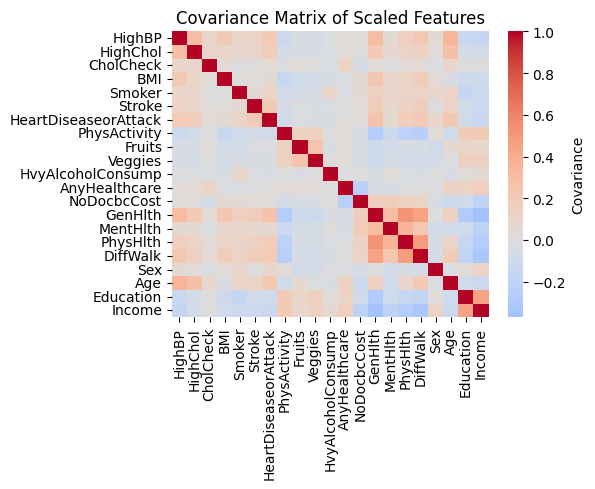

Covariance matrix shape: (21, 21)


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate covariance matrix
cov_matrix = np.cov(scaled_data.T)

# Display covariance matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cov_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    xticklabels=numeric_features,
    yticklabels=numeric_features,
    cbar_kws={"label": "Covariance"},
)
plt.title("Covariance Matrix of Scaled Features")
plt.tight_layout()
plt.savefig("images/covariance_matrix.svg", format="svg", bbox_inches="tight")
plt.show()

print(f"Covariance matrix shape: {cov_matrix.shape}")

# PCA

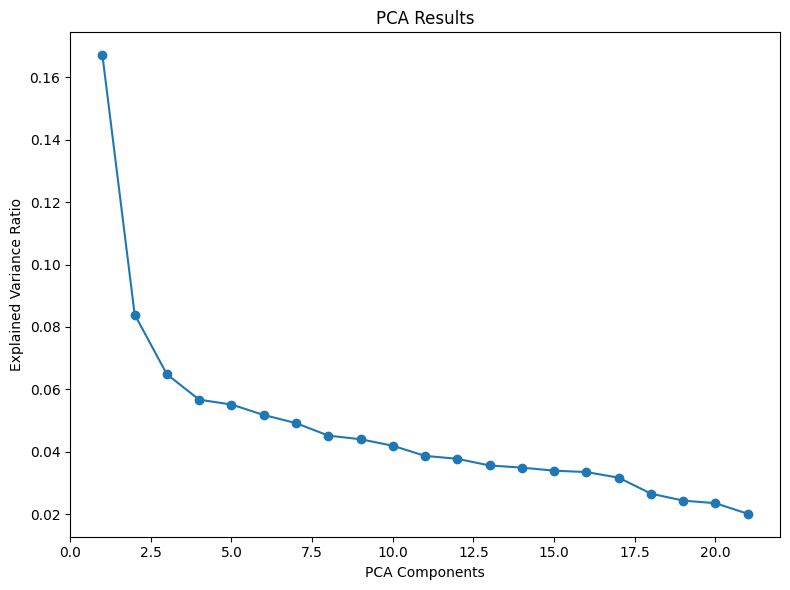

In [42]:
from sklearn.decomposition import PCA

pca = PCA().fit(scaled_data)

plt.figure(figsize=(8, 6))
plt.plot(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_, marker="o")
plt.xlabel("PCA Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Results")
plt.tight_layout()
plt.savefig("images/pca_explained_variance.svg", format="svg", bbox_inches="tight")
plt.show()

In [43]:
pca.explained_variance_ratio_

array([0.16713006, 0.08396704, 0.06480288, 0.05667649, 0.05512874,
       0.05176754, 0.04916833, 0.04515407, 0.04399236, 0.04190459,
       0.03864939, 0.03771927, 0.03557995, 0.03488982, 0.03391184,
       0.03346775, 0.03166342, 0.0265529 , 0.02430867, 0.02348267,
       0.02008222])

In [44]:
# Find number of components that explain at least 85% of variance
cumulative_variance = pca.explained_variance_ratio_.cumsum()
n_components = (cumulative_variance < 0.8).sum() + 1
print(f"Number of components to explain at least 80% variance: {n_components}")

Number of components to explain at least 80% variance: 14


In [45]:
pca = PCA(n_components=n_components).fit(scaled_data)
pca_data = pca.transform(scaled_data)
print(pca_data)

[[ 4.77569195 -0.43214148  0.3356638  ...  1.07069858  0.02771312
  -0.9365576 ]
 [ 0.57292634 -5.45915935 -1.55664967 ...  0.42521384  0.4095685
   1.99007186]
 [ 4.94131986 -1.79586563  2.02481371 ... -0.59093257 -1.31928458
   1.22113362]
 ...
 [-1.30555165 -1.71669629 -0.15111092 ... -1.01693462  0.00761598
   0.42516302]
 [ 0.46393464 -0.12676433 -0.14465724 ... -0.85688877 -0.6619505
  -0.30037722]
 [ 0.78648932  1.5785753  -0.31414497 ... -1.66225812  1.62052365
   0.01119061]]


### PCA Heatmap e Matrice di Covarianza

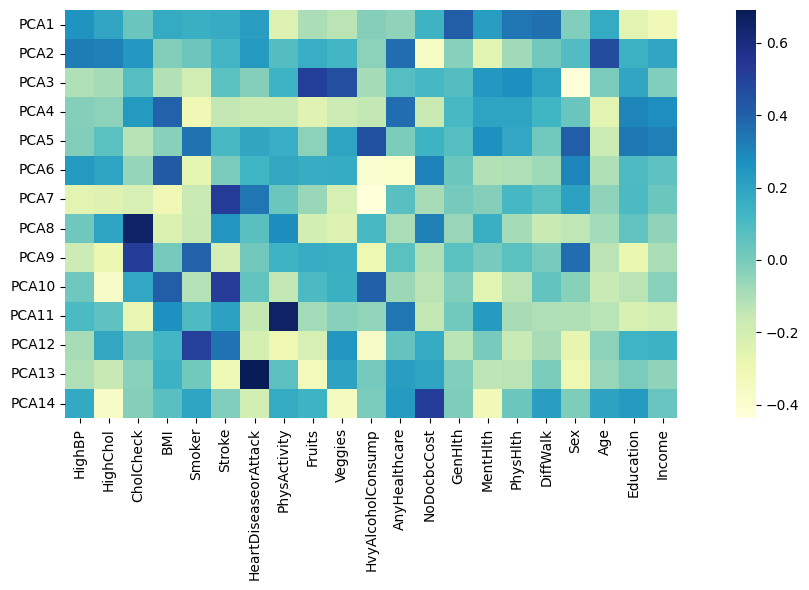

In [46]:
plt.figure(figsize=(12, 6))
ax = sns.heatmap(
    pca.components_,
    cmap="YlGnBu",
    yticklabels=["PCA" + str(x) for x in range(1, pca.n_components_ + 1)],
    xticklabels=list(numeric_features),
    cbar_kws={"orientation": "vertical"},
)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("images/pca_components_heatmap.svg", format="svg", bbox_inches="tight")
plt.show()

### Data Splitting

In [47]:
# 1. Data Preparation
X_pca = pca_data
y = df["Diabetes_binary"].values

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.3, random_state=42
)

print(f"Dimensioni Training Set: {X_train_pca.shape}")

Dimensioni Training Set: (177576, 14)


# Neural Network

In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.utils import class_weight
import tensorflow as tf

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc


def evaluate_and_plot(model, X_test, y_test, history, threshold=0.5, title_suffix=""):
    # Crea il suffisso per i nomi dei file (rimuove spazi e caratteri speciali)
    file_suffix = title_suffix.lower().replace(" ", "_").replace("-", "")

    # Predizioni e binarizzazione
    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > threshold).astype("int32")

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    title = "Matrice di Confusione" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(
        f"images/nn_confusion_matrix_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

    # Report di classificazione
    print("Report di Classificazione:")
    print(classification_report(y_test, y_pred))

    # Calcolo ROC-AUC
    fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    # Curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})"
    )
    plt.plot(
        [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier"
    )
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    title = "Curva ROC" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        f"images/nn_roc_curve_{file_suffix}.svg", format="svg", bbox_inches="tight"
    )
    plt.show()

    print(f"\nAUC Score: {roc_auc:.4f}")

    # Curve di Loss e Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get("loss", []), label="Train Loss")
    plt.plot(history.history.get("val_loss", []), label="Val Loss")
    plt.title("Model Loss" + (f" ({title_suffix})" if title_suffix else ""))
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history.get("accuracy", []), label="Train Accuracy")
    plt.plot(history.history.get("val_accuracy", []), label="Val Accuracy")
    plt.title("Model Accuracy" + (f" ({title_suffix})" if title_suffix else ""))
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        f"images/nn_training_curves_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

## No PCA

### Standard Dataset

In [ ]:
# 2. Creazione del Modello
model = Sequential()

# Strati Nascosti
model.add(Dense(128, input_shape=(FEATURES_NUMBER,), activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model.add(Dense(1, activation="sigmoid"))

# 3. Compilazione
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

# 4. Addestramento
history = model.fit(
    X_train, y_train, epochs=150, batch_size=256, verbose=1, validation_split=0.1
)

c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 13,185 (51.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8578 - loss: 0.3417 - val_accuracy: 0.8637 - val_loss: 0.3178
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8629 - loss: 0.3233 - val_accuracy: 0.8652 - val_loss: 0.3175
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8638 - loss: 0.3212 - val_accuracy: 0.8655 - val_loss: 0.3164
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8639 - loss: 0.3206 - val_accuracy: 0.8645 - val_loss: 0.3170
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8643 - loss: 0.3184 - val_accuracy: 0.8658 - val_loss: 0.3162
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8646 - loss: 0.3181 - val_accuracy: 0.8669 - val_loss: 0.3159
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8646 - loss: 0.3175 - val_accuracy: 0.8664 - val_loss: 0.3156
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8646 - loss: 0.3166 - val_accu

#### Results and Metrics

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 739us/step


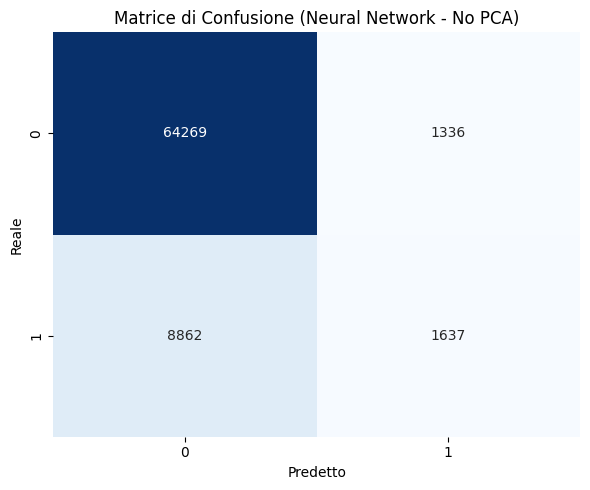

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93     65605
           1       0.55      0.16      0.24     10499

    accuracy                           0.87     76104
   macro avg       0.71      0.57      0.58     76104
weighted avg       0.83      0.87      0.83     76104



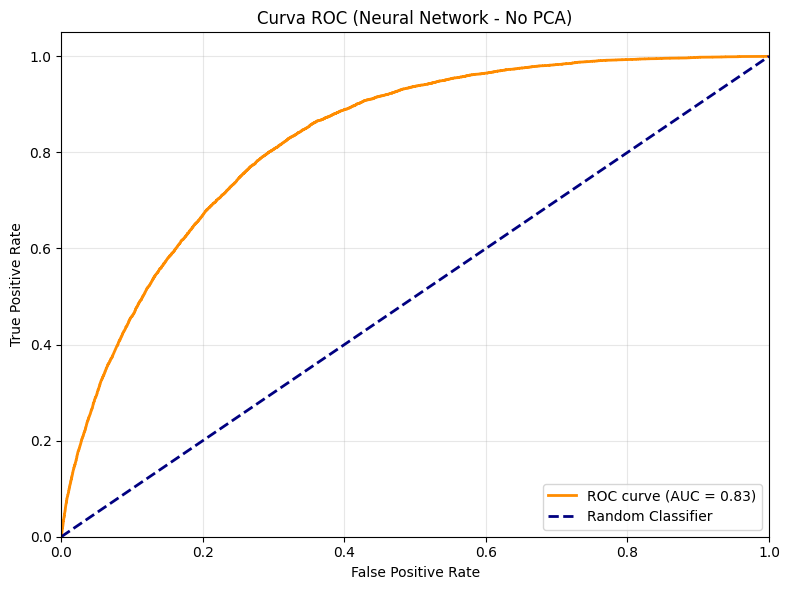


AUC Score: 0.8274


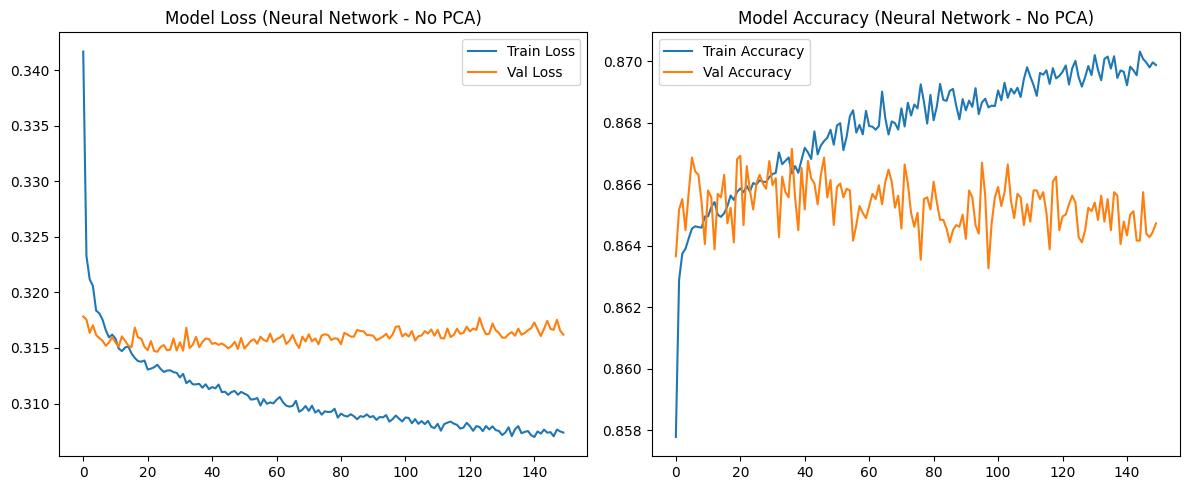

In [ ]:
# 5. Valutazione
evaluate_and_plot(model, X_test, y_test, history, title_suffix="NN - Standard - No PCA")

### Undersampling

In [ ]:
# 3. Creazione del Modello
model_pca_under = Sequential()
model_pca_under.add(Dense(64, input_shape=(FEATURES_NUMBER,), activation="relu"))
model_pca_under.add(Dropout(0.5))

model_pca_under.add(Dense(32, activation="relu"))
model_pca_under.add(Dropout(0.3))

model_pca_under.add(Dense(16, activation="relu"))
model_pca_under.add(Dropout(0.3))

model_pca_under.add(Dense(1, activation="sigmoid"))

model_pca_under.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# 4. Addestramento
history_pca_under = model_pca_under.fit(
    X_train_bal,
    y_train_bal,
    epochs=100,
    batch_size=128,
    verbose=1,
    validation_split=0.1,
)

Epoch 1/100


c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6890 - loss: 0.5892 - val_accuracy: 0.7357 - val_loss: 0.5320
Epoch 2/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7347 - loss: 0.5422 - val_accuracy: 0.7351 - val_loss: 0.5242
Epoch 3/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7408 - loss: 0.5350 - val_accuracy: 0.7383 - val_loss: 0.5272
Epoch 4/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7446 - loss: 0.5310 - val_accuracy: 0.7387 - val_loss: 0.5219
Epoch 5/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7458 - loss: 0.5266 - val_accuracy: 0.7397 - val_loss: 0.5224
Epoch 6/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7455 - loss: 0.5258 - val_accuracy: 0.7399 - val_loss: 0.5228
Epoch 7/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7462 - loss: 0.5227 - val_accuracy: 0.7375 - val_loss: 0.5214
Epoch 8/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7472 - loss: 0.5223 - val_accuracy: 0.7385

#### Results and Metrics

663/663 ━━━━━━━━━━━━━━━━━━━━ 1s 735us/step


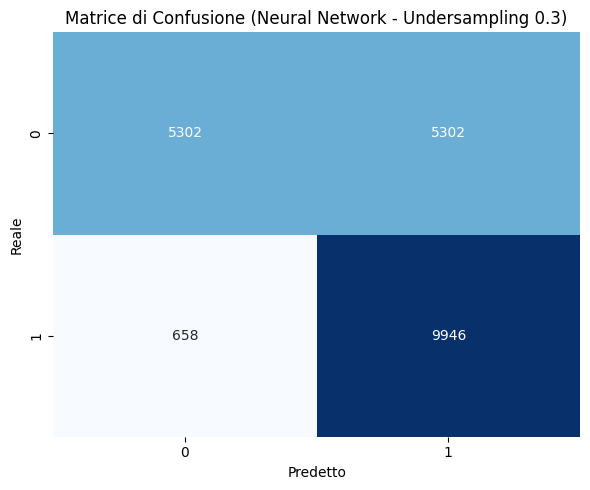

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.89      0.50      0.64     10604
           1       0.65      0.94      0.77     10604

    accuracy                           0.72     21208
   macro avg       0.77      0.72      0.70     21208
weighted avg       0.77      0.72      0.70     21208



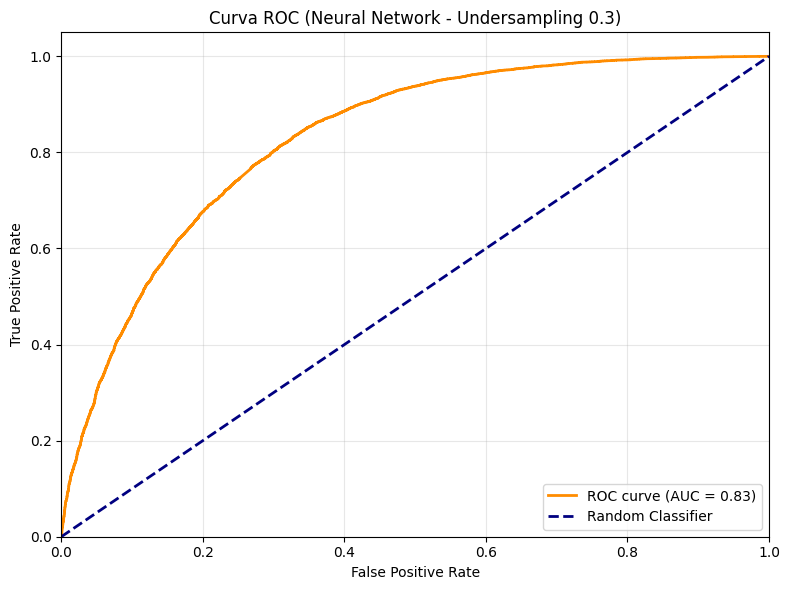


AUC Score: 0.8282


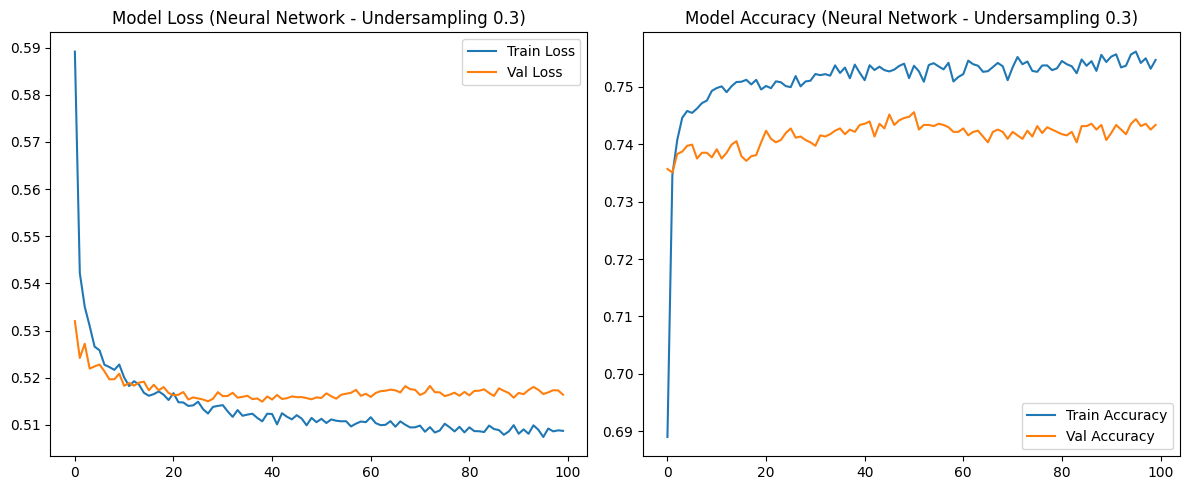

663/663 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step


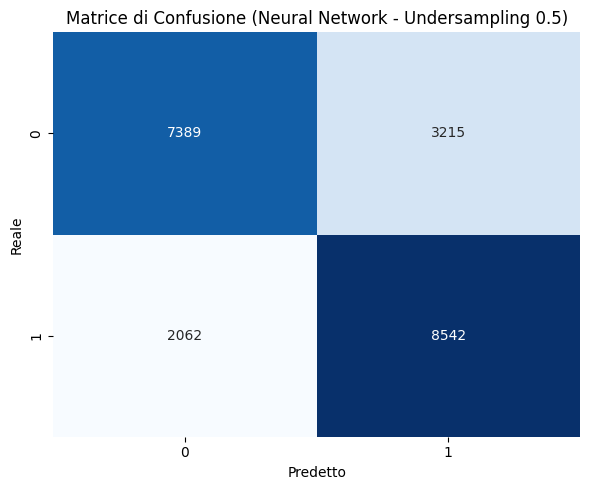

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.78      0.70      0.74     10604
           1       0.73      0.81      0.76     10604

    accuracy                           0.75     21208
   macro avg       0.75      0.75      0.75     21208
weighted avg       0.75      0.75      0.75     21208



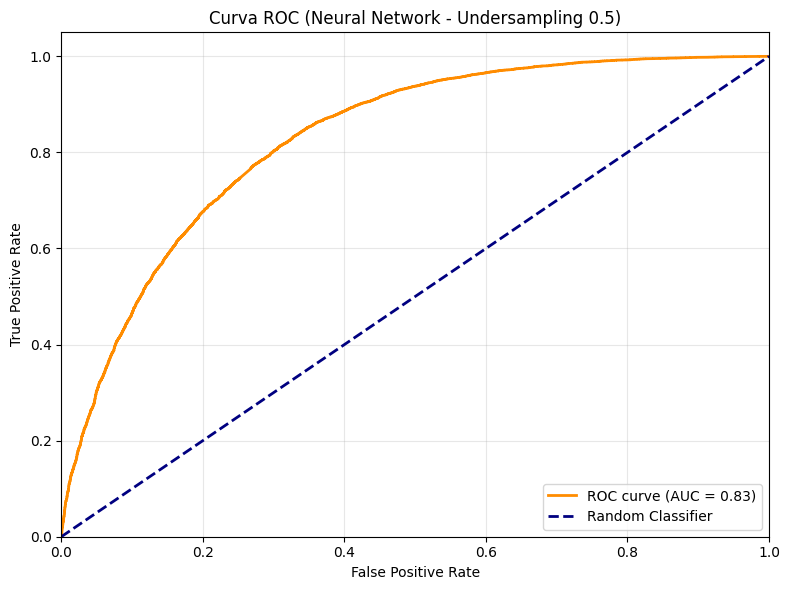


AUC Score: 0.8282


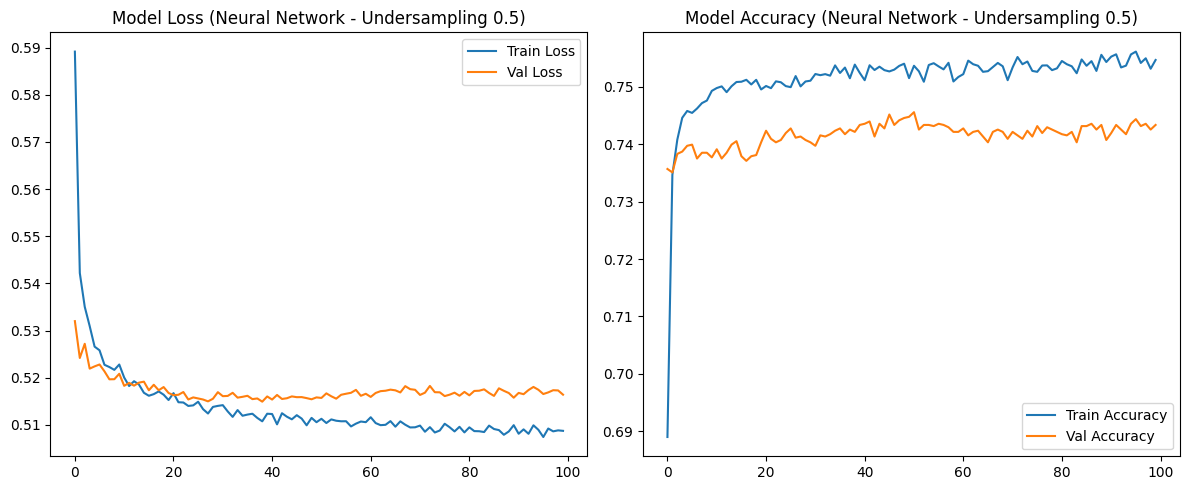

In [ ]:
for thres in [0.3, 0.5]:
    # 5. Valutazione
    evaluate_and_plot(
        model_pca_under,
        X_test_bal,
        y_test_bal,
        history_pca_under,
        threshold=thres,
        title_suffix=f"NN - Undersampling - No PCA (threshold={thres})",
    )

### Class Weights

In [ ]:
# 2. Calcolo dei Class Weights
class_weights_vals = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weights = dict(enumerate(class_weights_vals))
print(f"Pesi delle classi: {class_weights}")

model_no_pca_weighted = Sequential()

# Strati Nascosti
model_no_pca_weighted.add(Dense(128, input_shape=(FEATURES_NUMBER,), activation="relu"))
model_no_pca_weighted.add(Dropout(0.3))

model_no_pca_weighted.add(Dense(64, activation="relu"))
model_no_pca_weighted.add(Dropout(0.3))

model_no_pca_weighted.add(Dense(32, activation="relu"))
model_no_pca_weighted.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model_no_pca_weighted.add(Dense(1, activation="sigmoid"))

model_no_pca_weighted.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# 4. Addestramento con Class Weights
history_no_pca_weighted = model_no_pca_weighted.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
    class_weight=class_weights,
)

Pesi delle classi: {0: np.float64(0.5813434252826902), 1: np.float64(3.5733891415462633)}
Epoch 1/150


c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6959 - loss: 0.5340 - val_accuracy: 0.7035 - val_loss: 0.5010
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7039 - loss: 0.5173 - val_accuracy: 0.7080 - val_loss: 0.4996
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7107 - loss: 0.5134 - val_accuracy: 0.7118 - val_loss: 0.5088
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7177 - loss: 0.5114 - val_accuracy: 0.7246 - val_loss: 0.5039
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7145 - loss: 0.5115 - val_accuracy: 0.7197 - val_loss: 0.5128
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7206 - loss: 0.5091 - val_accuracy: 0.7127 - val_loss: 0.5157
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7185 - loss: 0.5087 - val_accuracy: 0.7201 - val_loss: 0.5058
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7200 - loss: 0.5090 - val_accuracy: 0.7172

#### Results and Metrics

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 779us/step


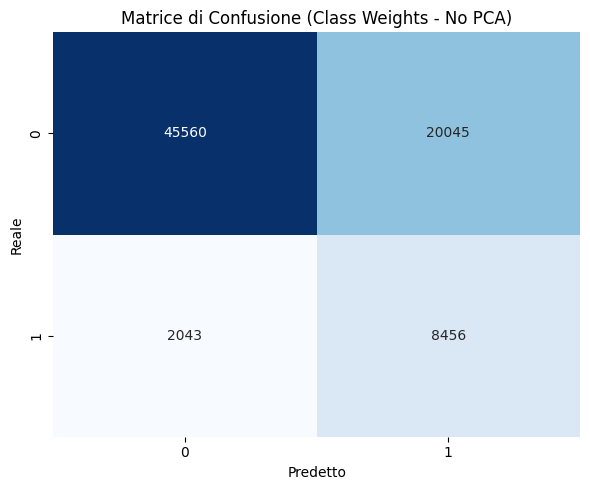

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     65605
           1       0.30      0.81      0.43     10499

    accuracy                           0.71     76104
   macro avg       0.63      0.75      0.62     76104
weighted avg       0.87      0.71      0.75     76104



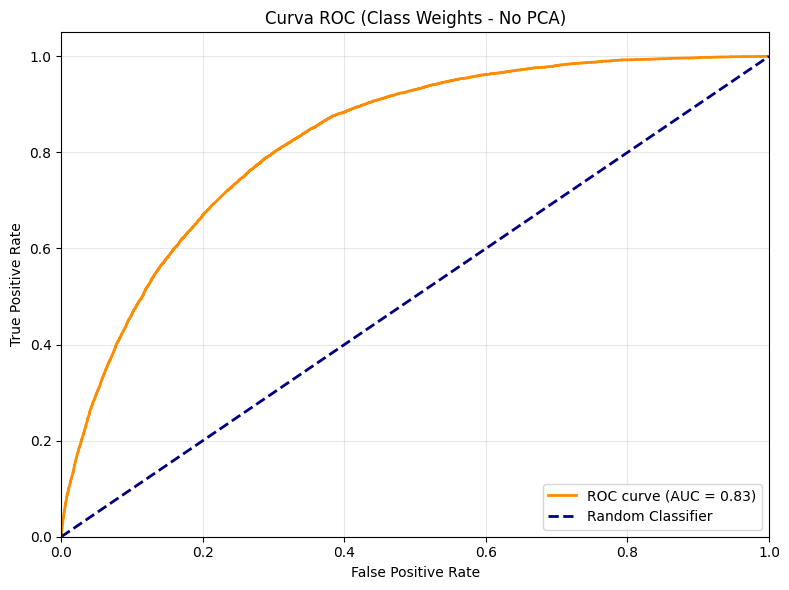


AUC Score: 0.8252


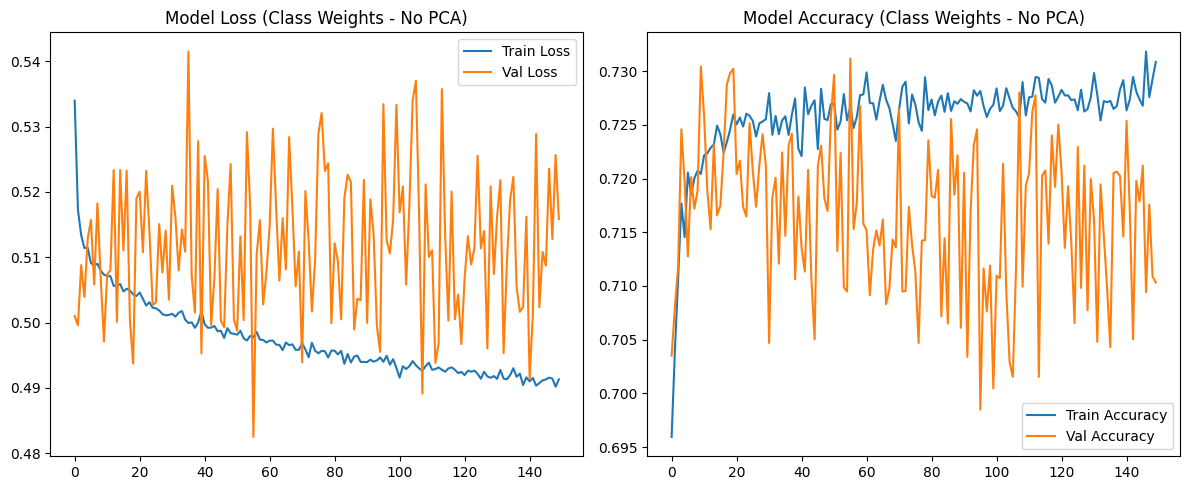

In [ ]:
# 5. Valutazione
evaluate_and_plot(
    model_no_pca_weighted,
    X_test,
    y_test,
    history_no_pca_weighted,
    title_suffix="NN - Class Weights - No PCA",
)

## PCA

### Class Weights

In [ ]:
# 2. Calcolo dei Class Weights
class_weights_vals = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train_pca), y=y_train_pca
)
class_weights = dict(enumerate(class_weights_vals))
print(f"Pesi delle classi: {class_weights}")

# 3. Creazione del Modello
model_pca_weighted = Sequential()
model_pca_weighted.add(Dense(32, input_shape=(n_components,), activation="relu"))
model_pca_weighted.add(Dropout(0.3))

model_pca_weighted.add(Dense(16, activation="relu"))
model_pca_weighted.add(Dropout(0.3))

model_pca_weighted.add(Dense(8, activation="relu"))
model_pca_weighted.add(Dropout(0.3))

# Strato di Output (1 neurone con attivazione sigmoid per output binario)
model_pca_weighted.add(Dense(1, activation="sigmoid"))

model_pca_weighted.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# 4. Addestramento con Class Weights
history_pca_weighted = model_pca_weighted.fit(
    X_train_pca,
    y_train_pca,
    epochs=150,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
    class_weight=class_weights,
)

Pesi delle classi: {0: np.float64(0.5813434252826902), 1: np.float64(3.5733891415462633)}
Epoch 1/150


c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6340 - loss: 0.6002 - val_accuracy: 0.6751 - val_loss: 0.5272
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6531 - loss: 0.5576 - val_accuracy: 0.6823 - val_loss: 0.5121
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6690 - loss: 0.5469 - val_accuracy: 0.6899 - val_loss: 0.5251
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6825 - loss: 0.5432 - val_accuracy: 0.6984 - val_loss: 0.5185
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6914 - loss: 0.5394 - val_accuracy: 0.7117 - val_loss: 0.5011
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6960 - loss: 0.5366 - val_accuracy: 0.7269 - val_loss: 0.5000
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7033 - loss: 0.5359 - val_accuracy: 0.7305 - val_loss: 0.5047
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7037 - loss: 0.5343 - val_accuracy: 0.7272

#### Results and Metrics

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 2s 890us/step


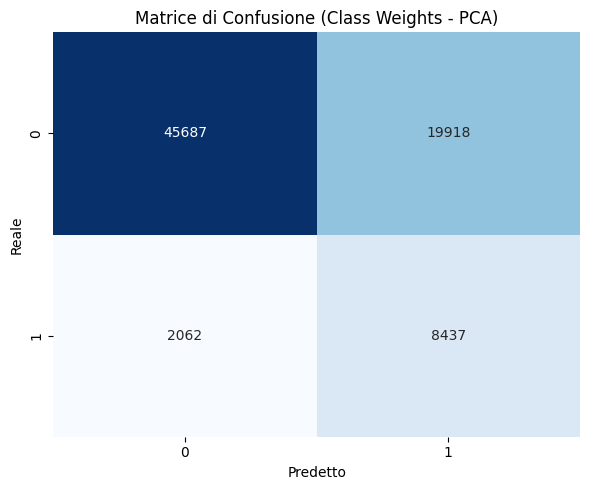

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     65605
           1       0.30      0.80      0.43     10499

    accuracy                           0.71     76104
   macro avg       0.63      0.75      0.62     76104
weighted avg       0.87      0.71      0.75     76104



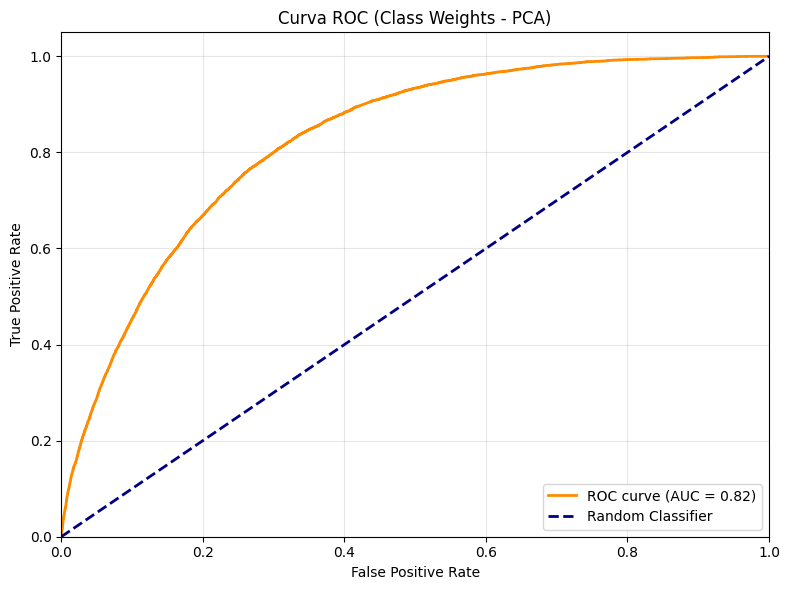


AUC Score: 0.8249


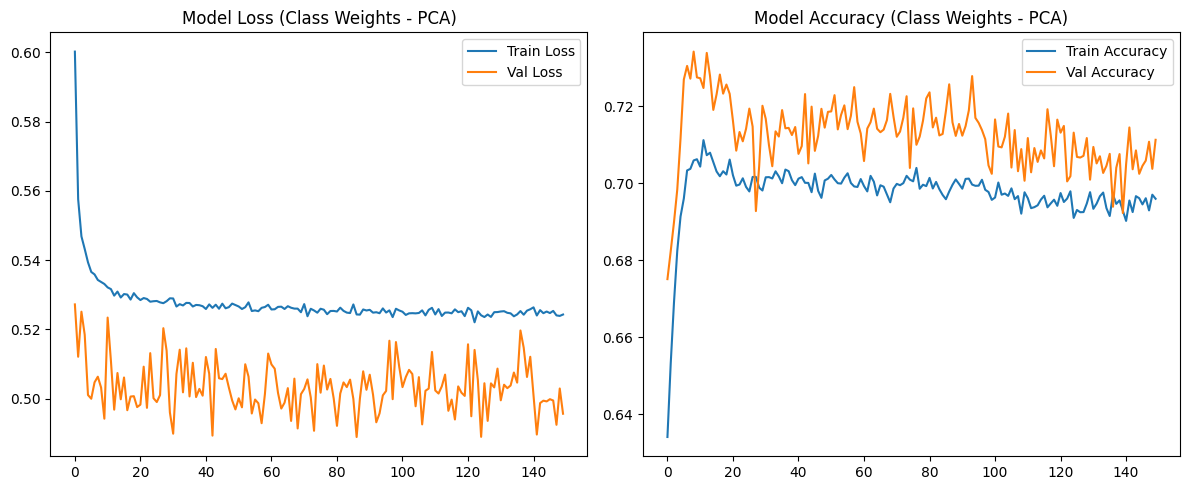

In [ ]:
# 5. Valutazione
evaluate_and_plot(
    model_pca_weighted,
    X_test_pca,
    y_test_pca,
    history_pca_weighted,
    title_suffix="NN - Class Weights - PCA",
)

# Decision Tree

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.tree import plot_tree, DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd
import re


def show_tree_metrics(tree, y_test, y_pred, title_suffix):
    file_suffix = title_suffix.lower().replace(" ", "_").replace("-", "")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    if hasattr(tree, "get_depth"):
        print(f"Profondità albero: {tree.get_depth()}")
        print(f"Numero di foglie: {tree.get_n_leaves()}")

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    title = "Matrice di Confusione" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(
        f"images/dt_confusion_matrix_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

    print("\n" + classification_report(y_test, y_pred))


def print_tree(tree, max_depth, title, feature_names=None):
    if feature_names is None:
        feature_names = numeric_features

    file_suffix = (
        title.lower().replace(" ", "_").replace("-", "") if title else "decision_tree"
    )
    plt.figure(figsize=(50, 24))
    plot_tree(
        tree,
        filled=True,
        feature_names=feature_names,
        class_names=["0", "1"],
        fontsize=8,
        max_depth=max_depth,
    )
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"images/dt_{file_suffix}.svg", format="svg", bbox_inches="tight")
    plt.show()

In [ ]:
def plot_feature_importance(tree, feature_names, title_suffix, top_n=None):
    file_suffix = title_suffix.lower().replace(" ", "_").replace("-", "")

    # Ottieni importanze
    importances = tree.feature_importances_

    # Crea DataFrame per facilitare l'ordinamento
    importance_df = pd.DataFrame(
        {"feature": feature_names, "importance": importances}
    ).sort_values("importance", ascending=False)

    # Filtra top_n se specificato
    if top_n is not None:
        importance_df = importance_df.head(top_n)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(importance_df)), importance_df["importance"])
    plt.yticks(range(len(importance_df)), importance_df["feature"])
    plt.xlabel("Feature Importance")
    plt.ylabel("Features")
    title = "Feature Importance" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(
        f"images/dt_feature_importance_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

    # Stampa anche i valori numerici
    print(f"\nFeature Importance{' (' + title_suffix + ')' if title_suffix else ''}:")
    print(importance_df.to_string(index=False))

In [ ]:
def run_grid_search(
    X_train, y_train, param_grid, class_weight="balanced", cv=5, scoring="f1"
):
    base_model = DecisionTreeClassifier(random_state=42, class_weight=class_weight)

    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )

    grid_search.fit(X_train, y_train)

    print(f"\n{'='*60}")
    print(f"RISULTATI GRID SEARCH (scoring={scoring}, cv={cv})")
    print(f"{'='*60}")
    print(f"Migliori parametri: {grid_search.best_params_}")
    print(f"Miglior score ({scoring}): {grid_search.best_score_:.4f}")
    print(f"{'='*60}\n")

    return grid_search.best_estimator_, grid_search

In [ ]:
dt_param_grid = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
    "ccp_alpha": [0, 0.0001, 0.0005, 0.001, 0.005, 0.01],
}

## No PCA

### Standard Dataset

In [ ]:
dt_standard, grid_search_standard = run_grid_search(
    X_train, y_train, dt_param_grid, class_weight=None
)
y_pred_standard = dt_standard.predict(X_test)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits

RISULTATI GRID SEARCH (scoring=f1, cv=5)
Migliori parametri: {'ccp_alpha': 0, 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Miglior score (f1): 0.3099



#### Results and Metrics

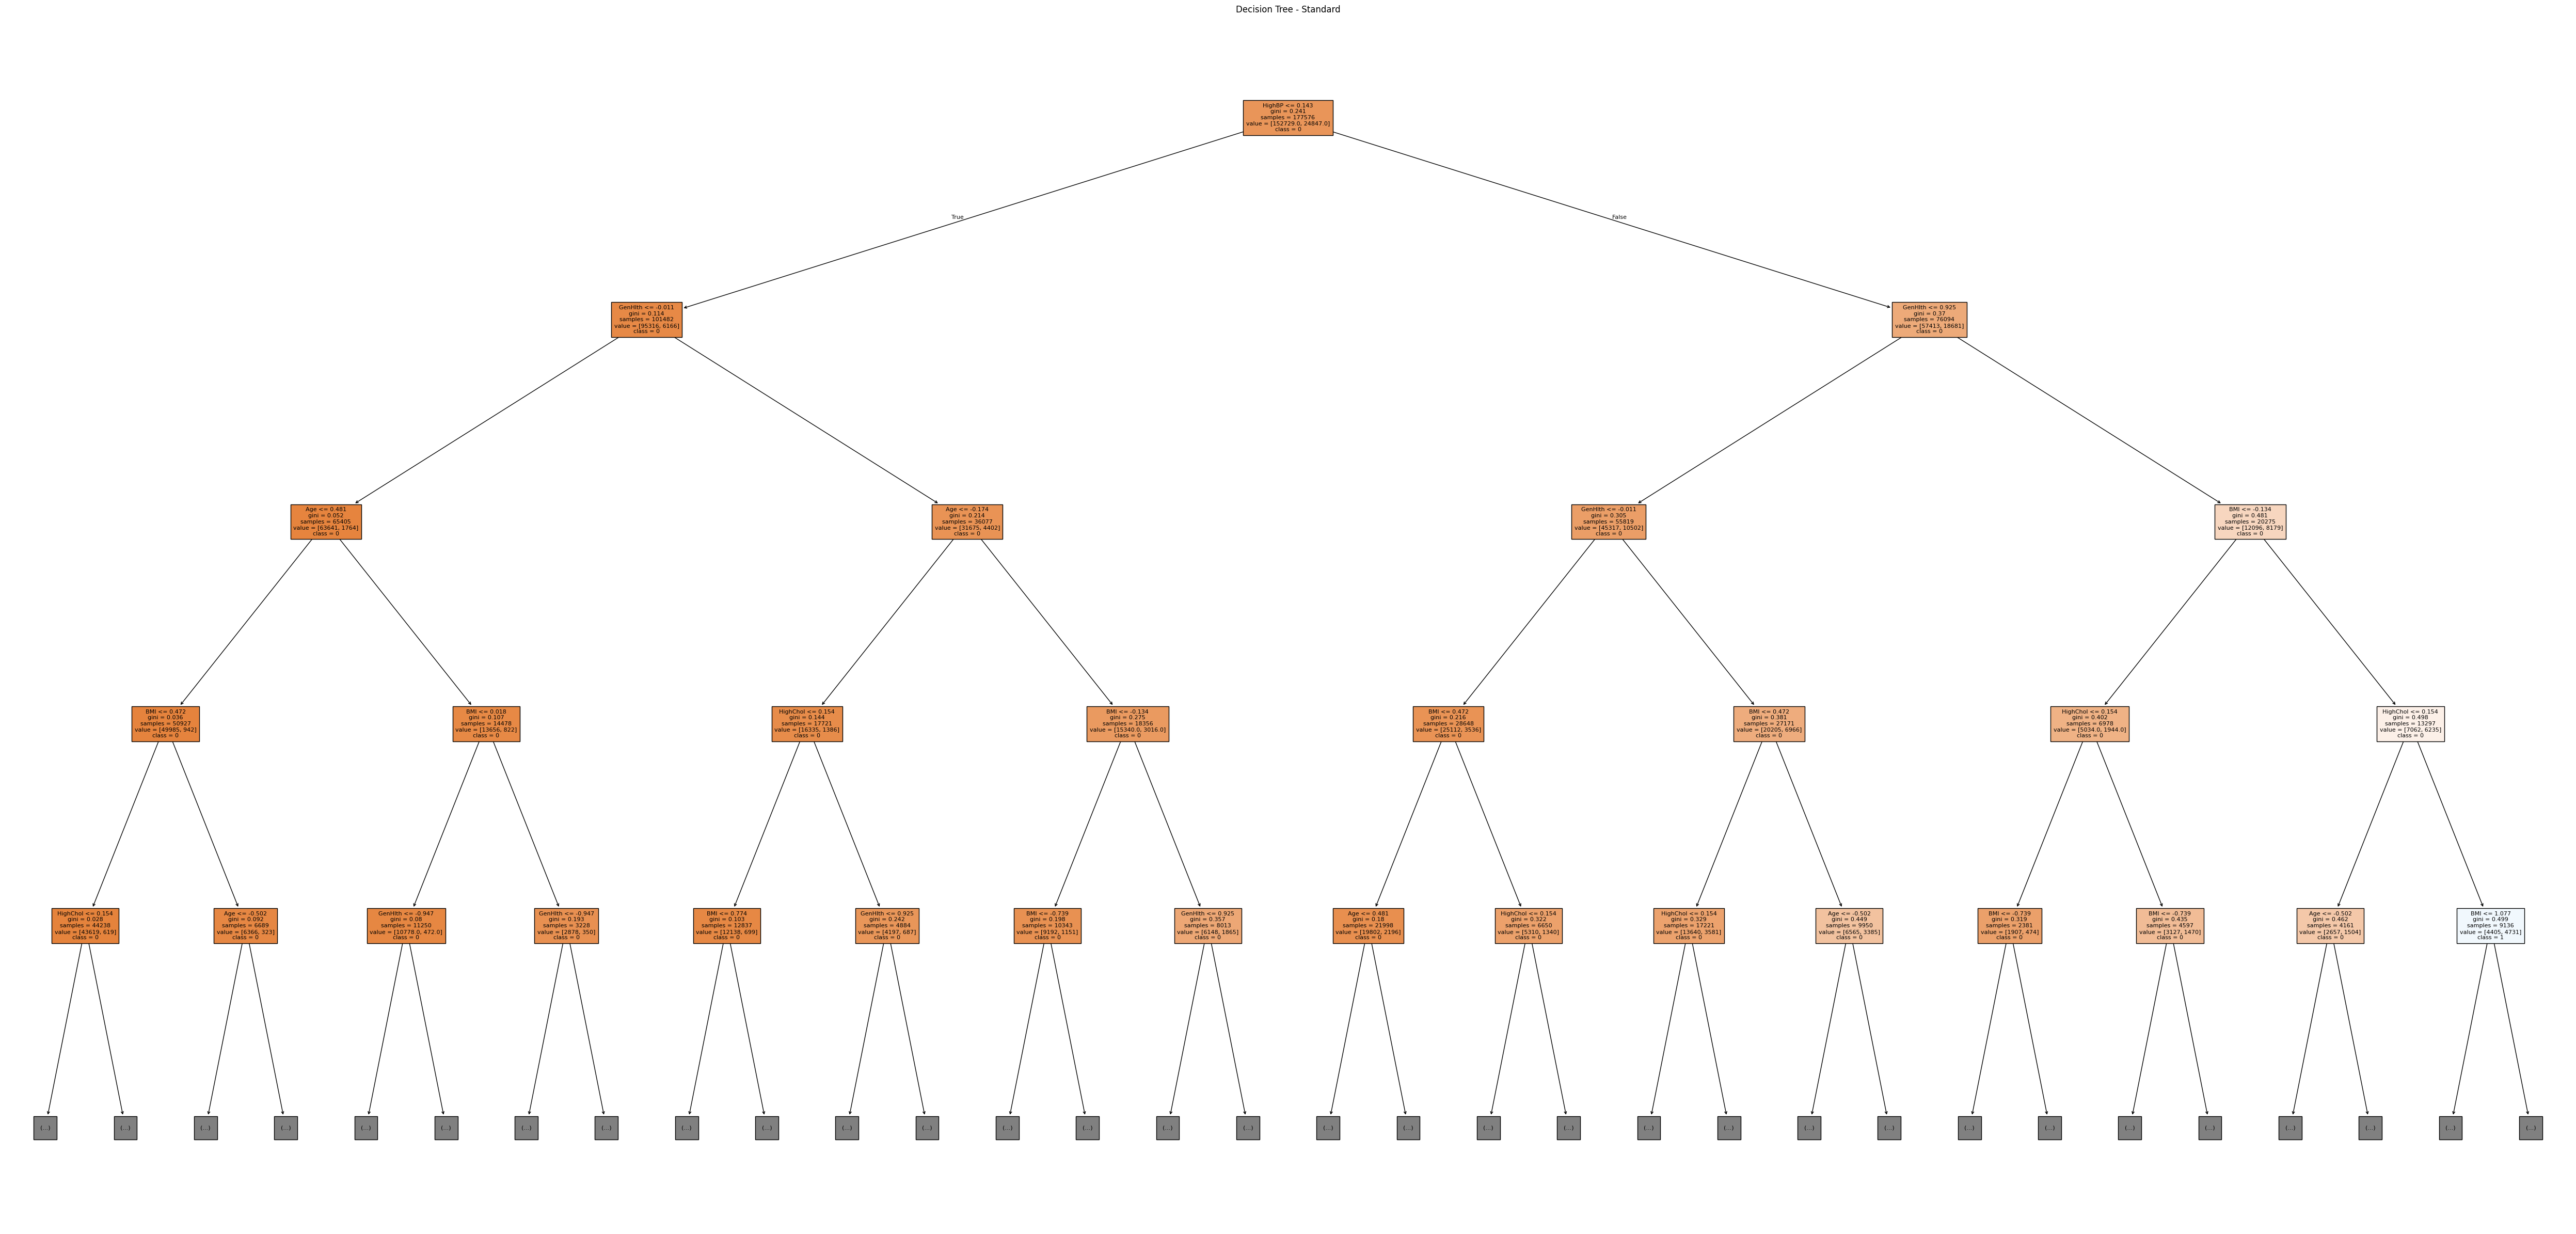

Accuracy: 0.7980
Profondità albero: 38
Numero di foglie: 32829


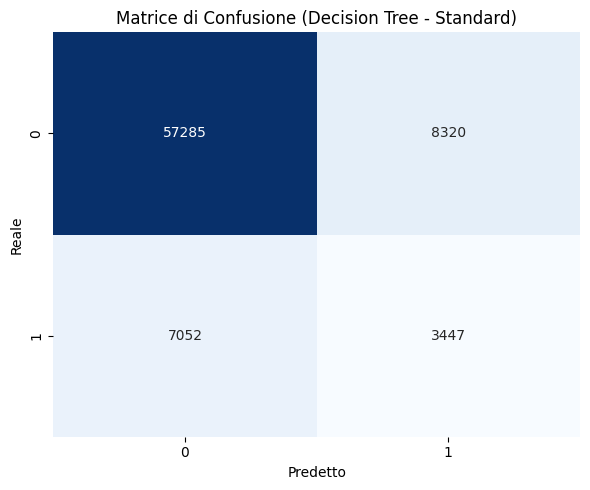


              precision    recall  f1-score   support

           0       0.89      0.87      0.88     65605
           1       0.29      0.33      0.31     10499

    accuracy                           0.80     76104
   macro avg       0.59      0.60      0.60     76104
weighted avg       0.81      0.80      0.80     76104



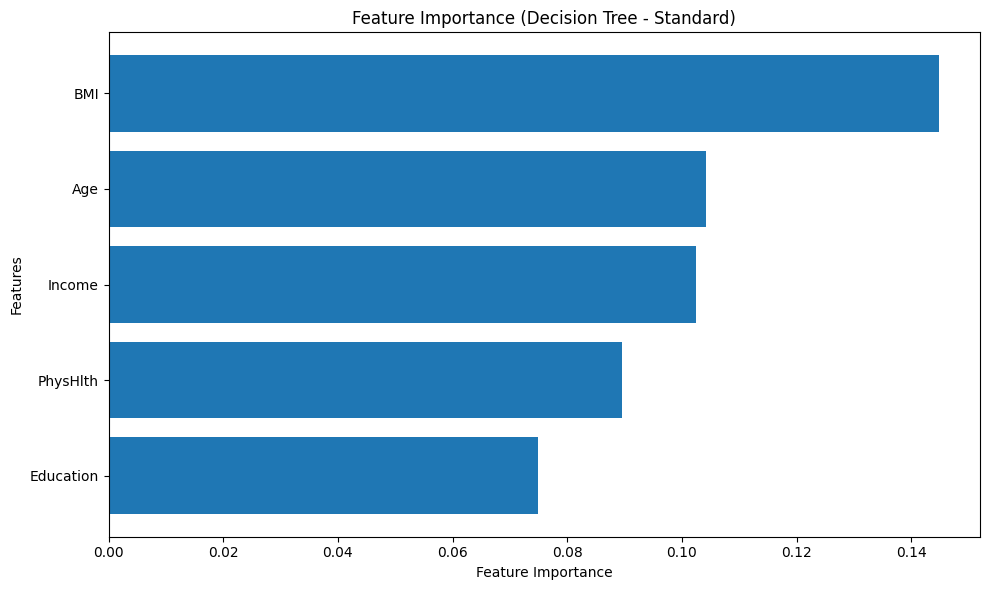


Feature Importance (Decision Tree - Standard):
  feature  importance
      BMI    0.144732
      Age    0.104101
   Income    0.102435
 PhysHlth    0.089473
Education    0.074885


In [ ]:
print_tree(
    dt_standard,
    max_depth=4,
    title="DT - Standard - No PCA",
    feature_names=numeric_features,
)
show_tree_metrics(
    dt_standard, y_test, y_pred_standard, title_suffix="DT - Standard - No PCA"
)
plot_feature_importance(
    dt_standard,
    feature_names=numeric_features,
    title_suffix="DT - Standard - No PCA",
    top_n=5,
)

### Balanced Dataset

In [ ]:
dt_best_bal, grid_results_bal = run_grid_search(
    X_train_bal,
    y_train_bal,
    dt_param_grid,
    class_weight=None,
    scoring="f1",
)

# Valutazione sul test set bilanciato
y_pred_best_bal = dt_best_bal.predict(X_test_bal)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits

RISULTATI GRID SEARCH (scoring=f1, cv=5)
Migliori parametri: {'ccp_alpha': 0.0001, 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Miglior score (f1): 0.7473



#### Results and Metrics

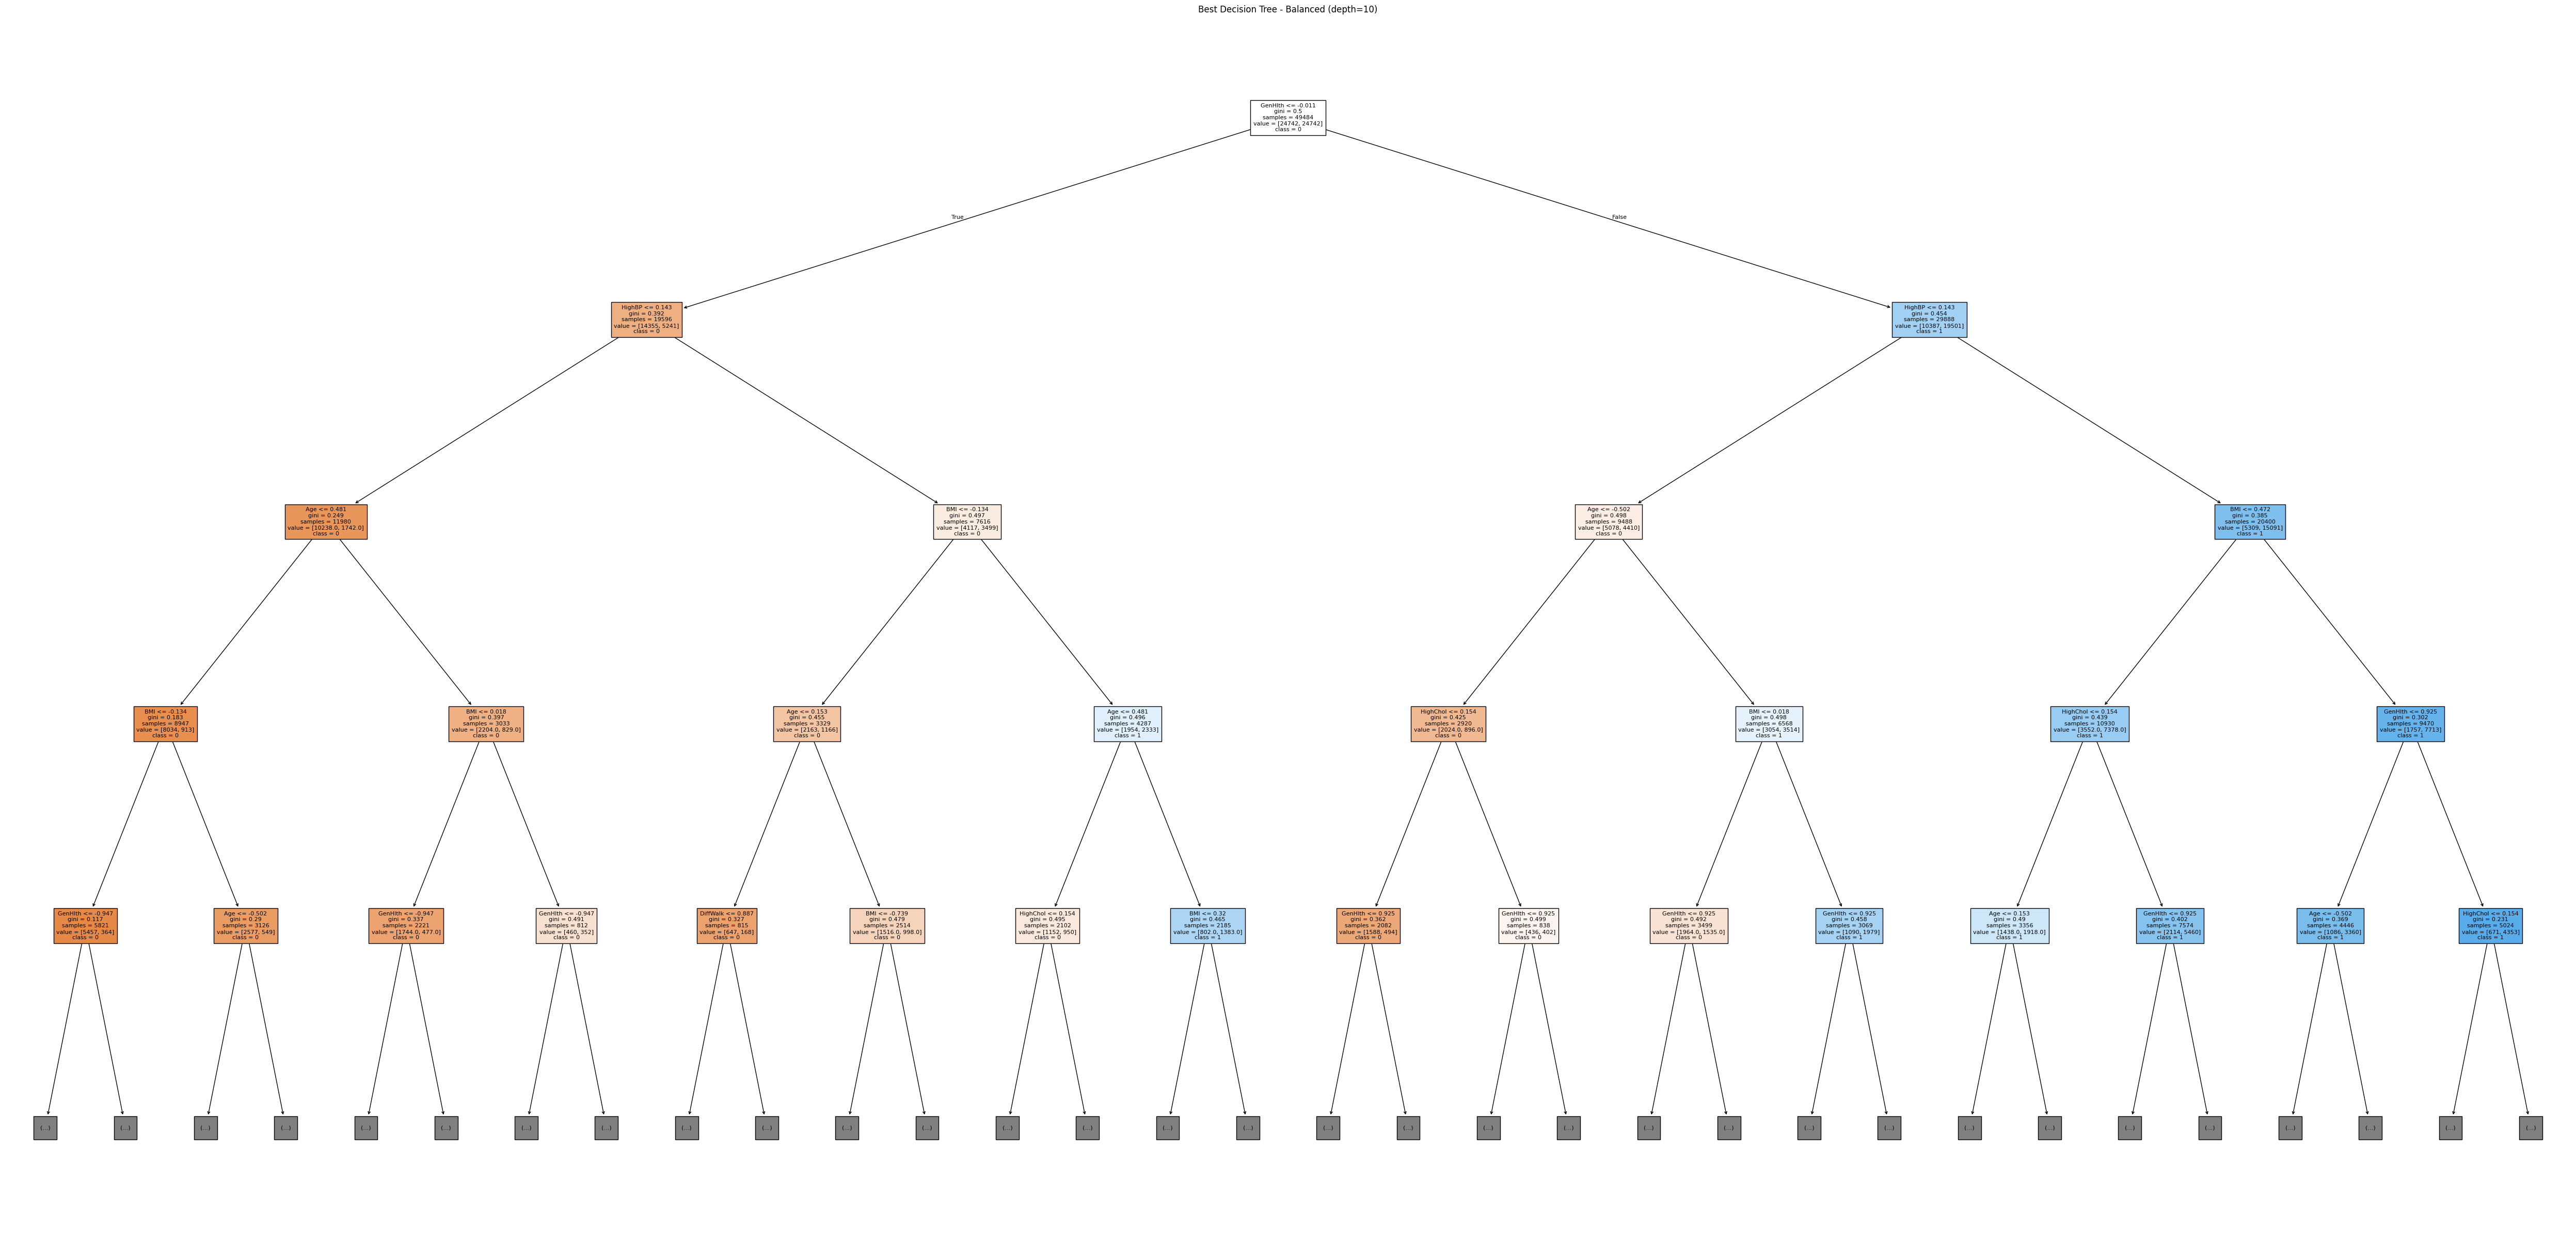

Accuracy: 0.7414
Profondità albero: 10
Numero di foglie: 110


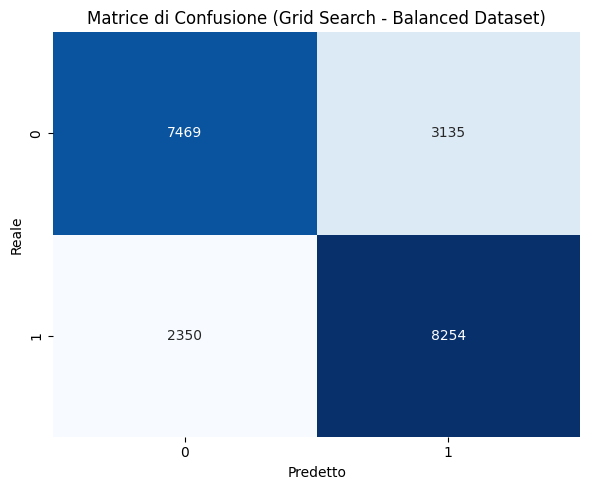


              precision    recall  f1-score   support

           0       0.76      0.70      0.73     10604
           1       0.72      0.78      0.75     10604

    accuracy                           0.74     21208
   macro avg       0.74      0.74      0.74     21208
weighted avg       0.74      0.74      0.74     21208



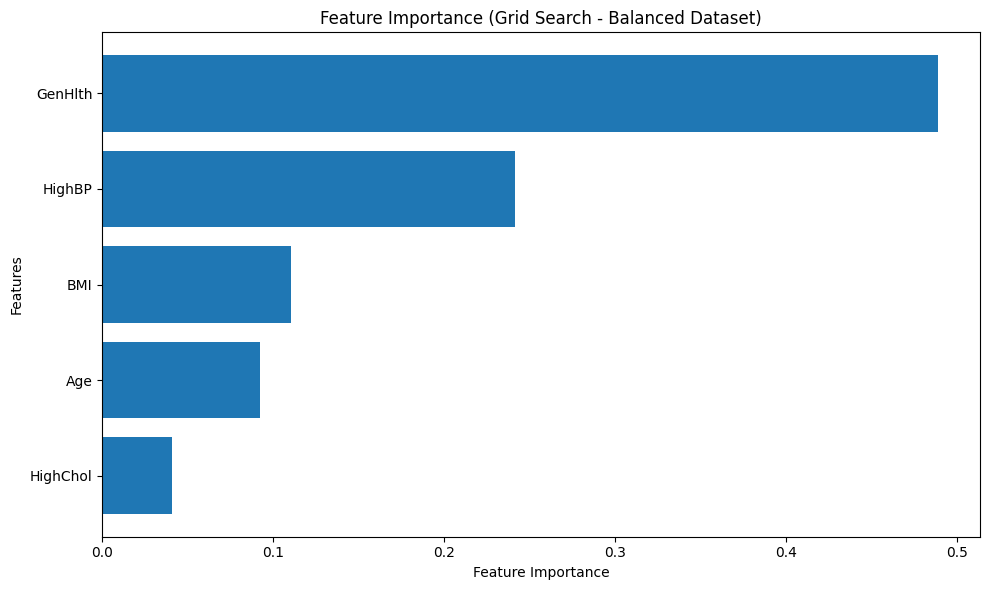


Feature Importance (Grid Search - Balanced Dataset):
 feature  importance
 GenHlth    0.489174
  HighBP    0.241489
     BMI    0.110761
     Age    0.092132
HighChol    0.040715


In [ ]:
print_tree(dt_best_bal, 4, f"DT - Undersampling - No PCA")
show_tree_metrics(
    dt_best_bal, y_test_bal, y_pred_best_bal, "DT - Undersampling - No PCA"
)
# Visualizza Feature Importance
plot_feature_importance(
    dt_best_bal, numeric_features, "DT - Undersampling - No PCA", top_n=5
)

### Class Weight

In [ ]:
# Grid Search con class_weight='balanced' per gestire lo sbilanciamento
dt_best, grid_results = run_grid_search(
    X_train, y_train, dt_param_grid, class_weight="balanced", scoring="f1"
)

# Valutazione sul test set
y_pred_best = dt_best.predict(X_test)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits

RISULTATI GRID SEARCH (scoring=f1, cv=5)
Migliori parametri: {'ccp_alpha': 0, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
Miglior score (f1): 0.4310



#### Results and Metrics

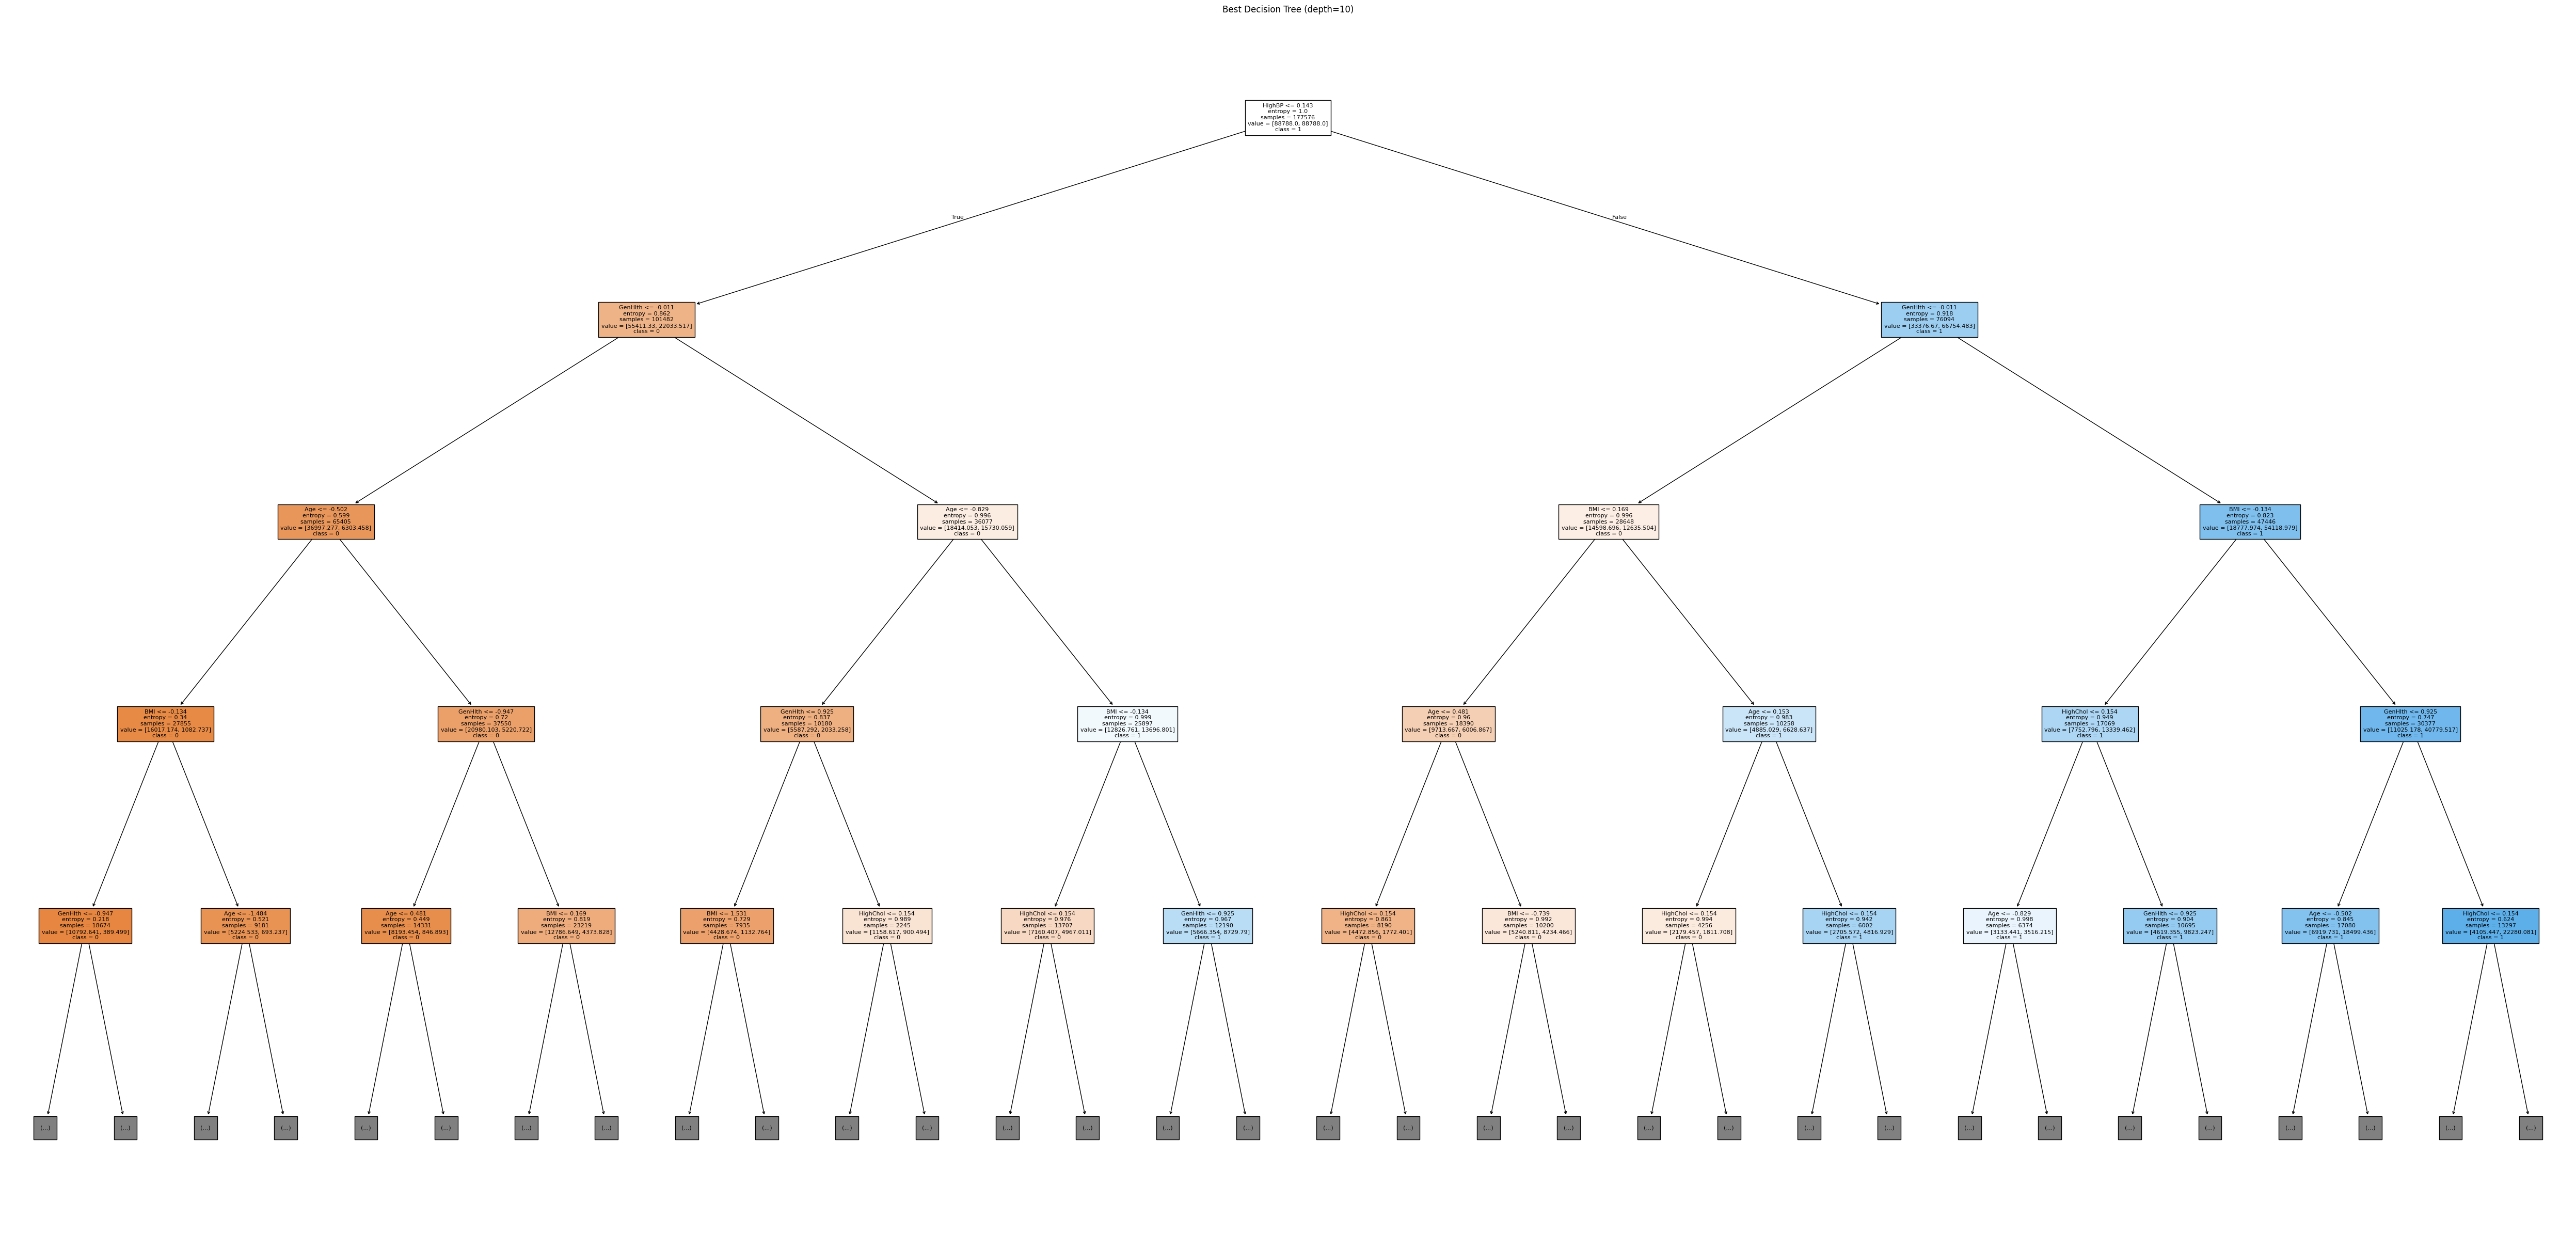

Accuracy: 0.7127
Profondità albero: 10
Numero di foglie: 814


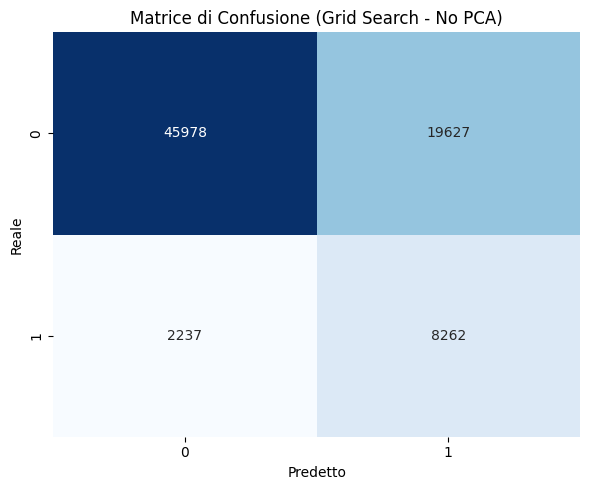


              precision    recall  f1-score   support

           0       0.95      0.70      0.81     65605
           1       0.30      0.79      0.43     10499

    accuracy                           0.71     76104
   macro avg       0.62      0.74      0.62     76104
weighted avg       0.86      0.71      0.76     76104



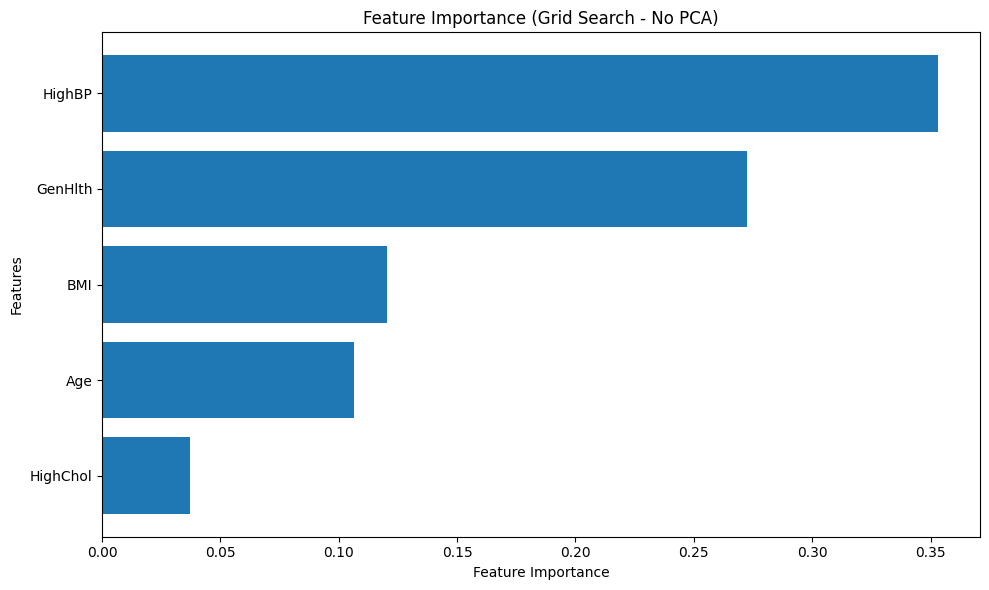


Feature Importance (Grid Search - No PCA):
 feature  importance
  HighBP    0.353217
 GenHlth    0.272532
     BMI    0.120349
     Age    0.106241
HighChol    0.037030


In [ ]:
print_tree(dt_best, 4, f"DT - Class Weights - No PCA")
show_tree_metrics(dt_best, y_test, y_pred_best, "DT - Class Weights - No PCA")
# Visualizza Feature Importance
plot_feature_importance(
    dt_best, numeric_features, "DT - Class Weights - No PCA", top_n=5
)

## PCA

### Class Weight

In [ ]:
# Feature names per PCA
pca_feature_names = [f"PC{i+1}" for i in range(n_components)]

dt_pca_best = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=10,
    ccp_alpha=0.0001,
)
dt_pca_best.fit(X_train_pca, y_train_pca)

# Valutazione sul test set PCA
y_pred_pca_best = dt_pca_best.predict(X_test_pca)

#### Results and Metrics

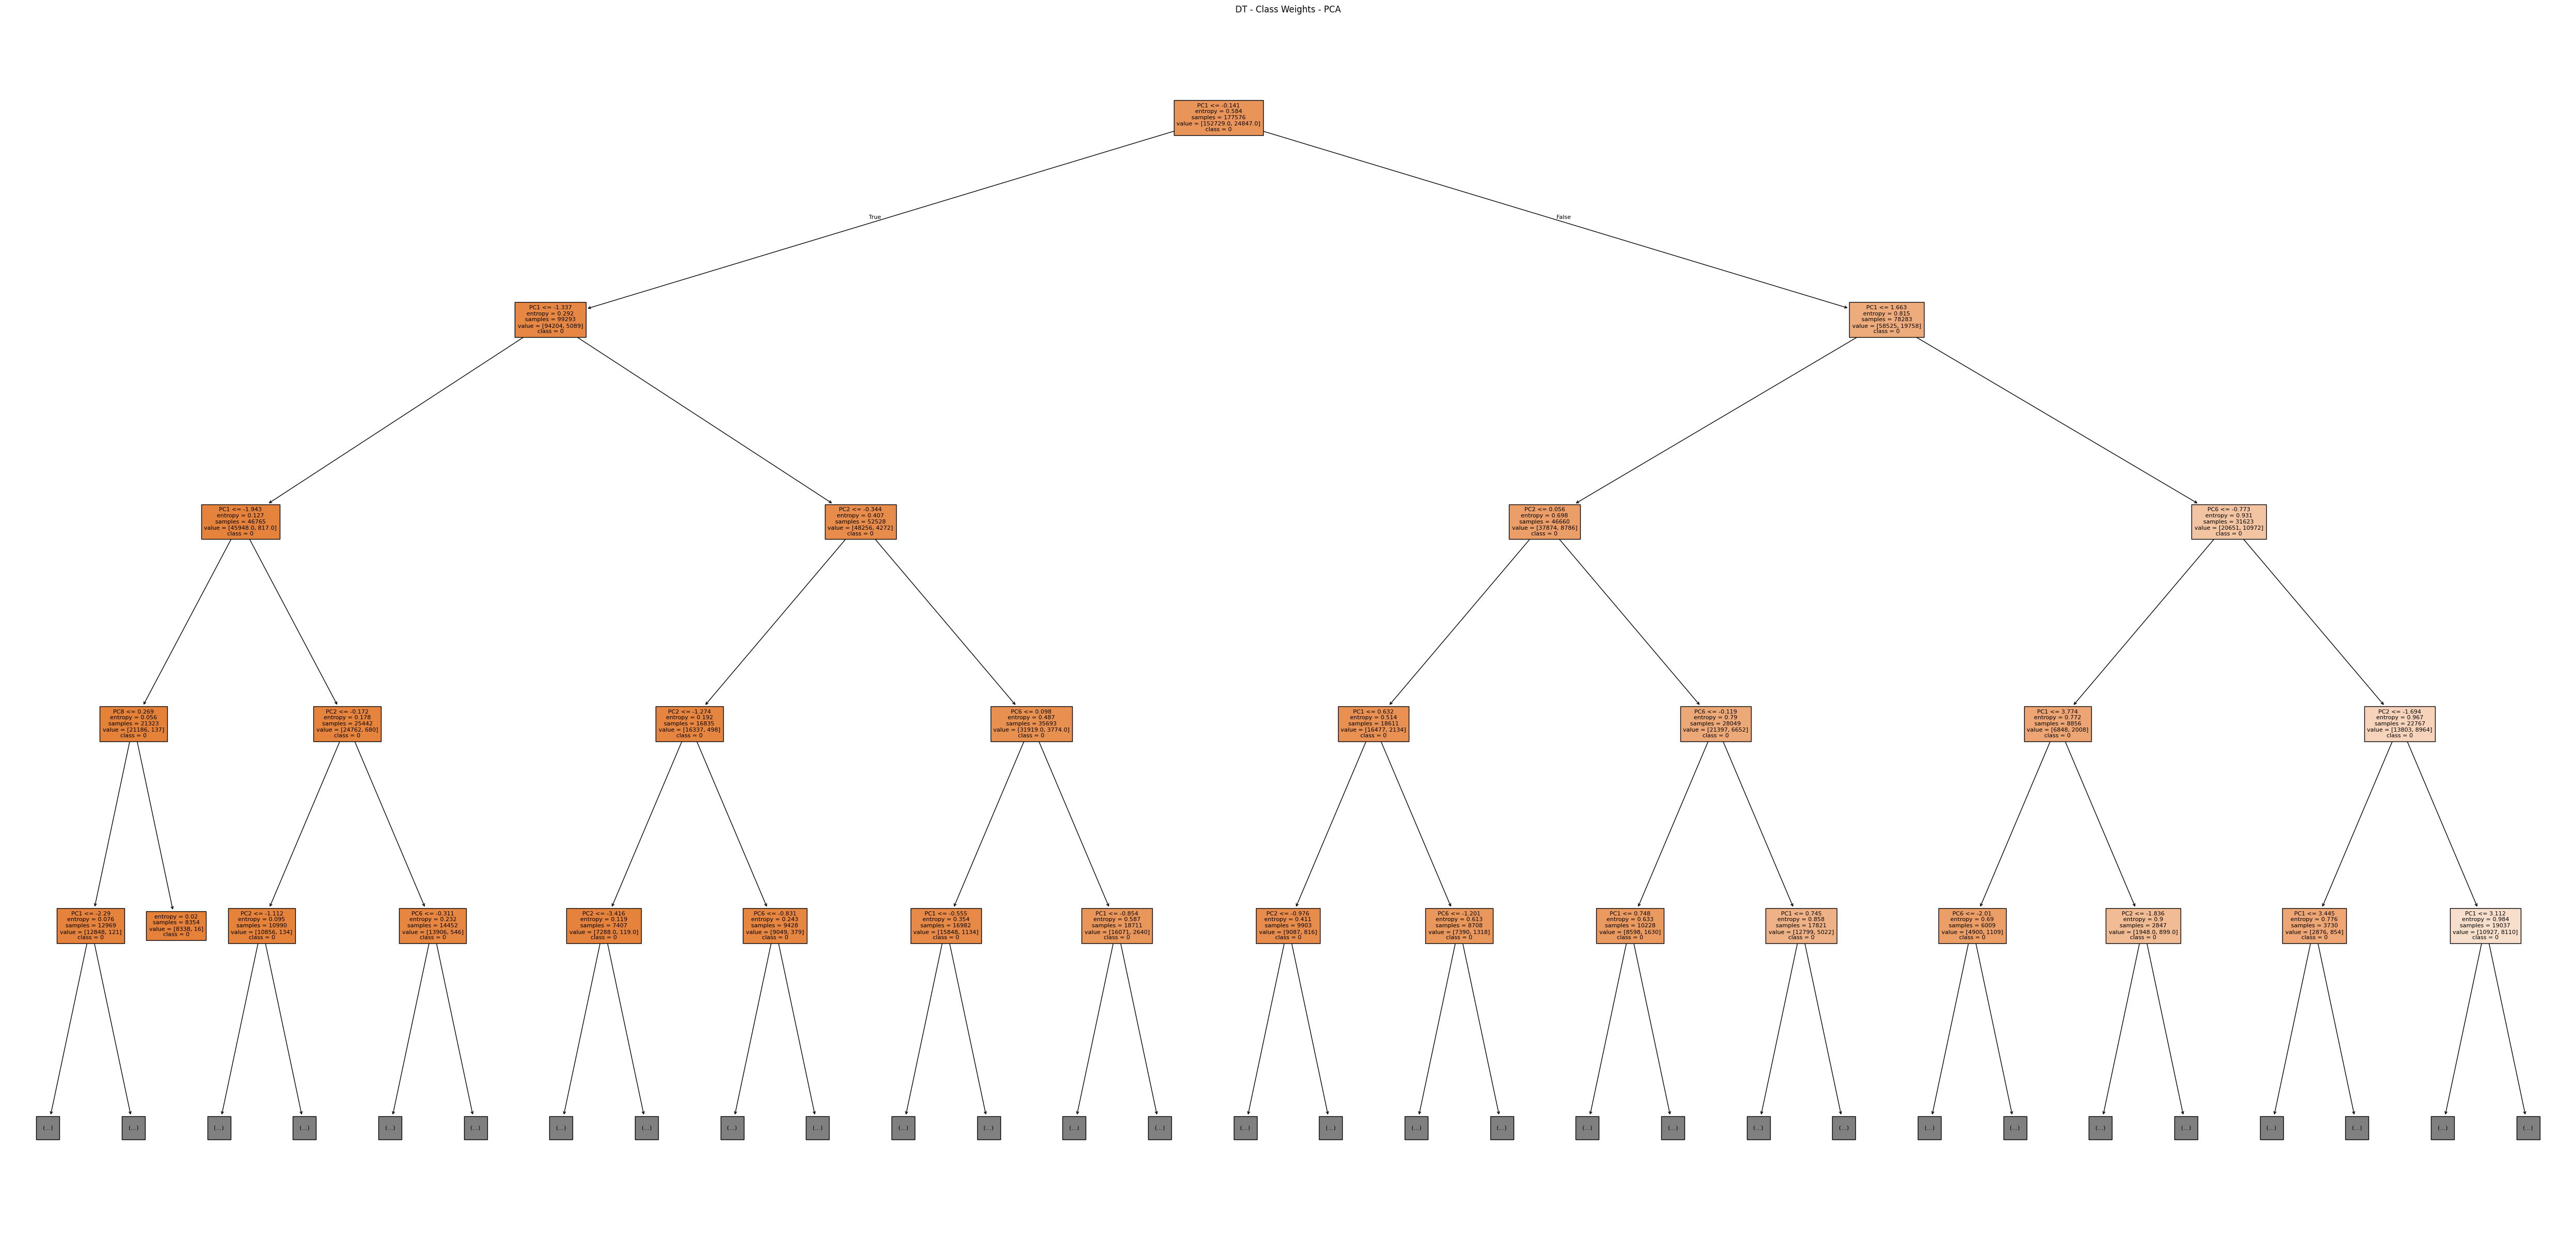

Accuracy: 0.8640
Profondità albero: 9
Numero di foglie: 80


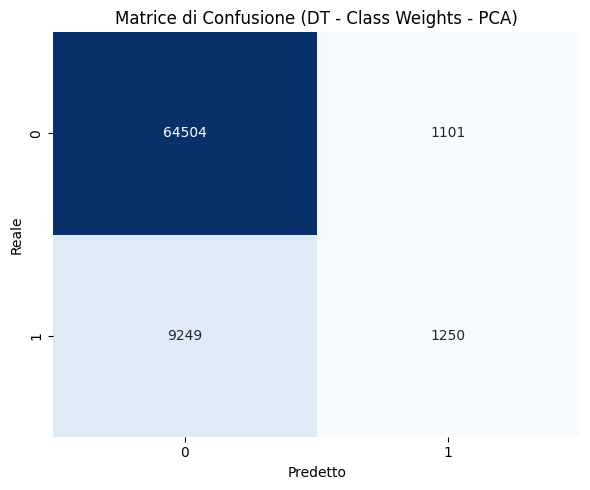


              precision    recall  f1-score   support

           0       0.87      0.98      0.93     65605
           1       0.53      0.12      0.19     10499

    accuracy                           0.86     76104
   macro avg       0.70      0.55      0.56     76104
weighted avg       0.83      0.86      0.82     76104



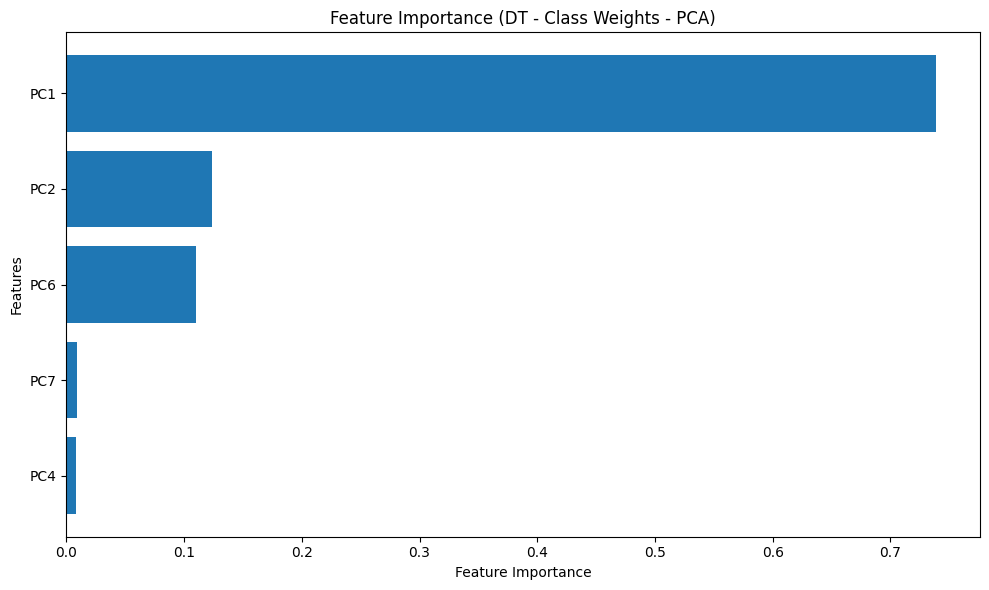


Feature Importance (DT - Class Weights - PCA):
feature  importance
    PC1    0.739073
    PC2    0.124141
    PC6    0.110283
    PC7    0.009037
    PC4    0.007835


In [ ]:
print_tree(
    dt_pca_best,
    4,
    f"DT - Class Weights - PCA",
    feature_names=pca_feature_names,
)
show_tree_metrics(dt_pca_best, y_test_pca, y_pred_pca_best, "DT - Class Weights - PCA")
# Visualizza Feature Importance per PCA
plot_feature_importance(
    dt_pca_best, pca_feature_names, "DT - Class Weights - PCA", top_n=5
)